In [1]:
import sys
import optuna
from dotenv import load_dotenv
from utils import analyze_strategies

sys.path.append("..")
from models.feature_engineering import get_mask, round_to_step, get_return
from models.etl_pipeline_local import get_btts_table

load_dotenv()

True

# 1. BTTS

In [2]:
target_col = "btts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/greedy_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

top_trials = sorted(study.trials, key=lambda t: -t.value)

Totale trial salvati: 1
Best assoluto: -0.16458952181487385 {'goalNoGoal_chance_goalHome_use_min': True, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 30.0, 'goalNoGoal_chance_goalHome_max': 82.5, 'goalNoGoal_chance_goalAway_use_min': False, 'goalNoGoal_chance_goalAway_use_max': True, 'goalNoGoal_chance_goalAway_min': 55.0, 'goalNoGoal_chance_goalAway_max': 65.0, 'goalNoGoal_comparison_affini_use_min': False, 'goalNoGoal_comparison_affini_use_max': True, 'goalNoGoal_comparison_affini_min': 18000, 'goalNoGoal_comparison_affini_max': 22000, 'underOver_chance_over15HT_use_min': False, 'underOver_chance_over15HT_use_max': True, 'underOver_chance_over15HT_min': 55, 'underOver_chance_over15HT_max': 65, 'underOver_comparison_affini_use_min': True, 'underOver_comparison_affini_use_max': False, 'underOver_comparison_affini_min': 16000, 'underOver_comparison_affini_max': 18000, 'evaluation_valScala_cat_idx': 18, 'evaluation_valMetrica_cat_idx': 143}


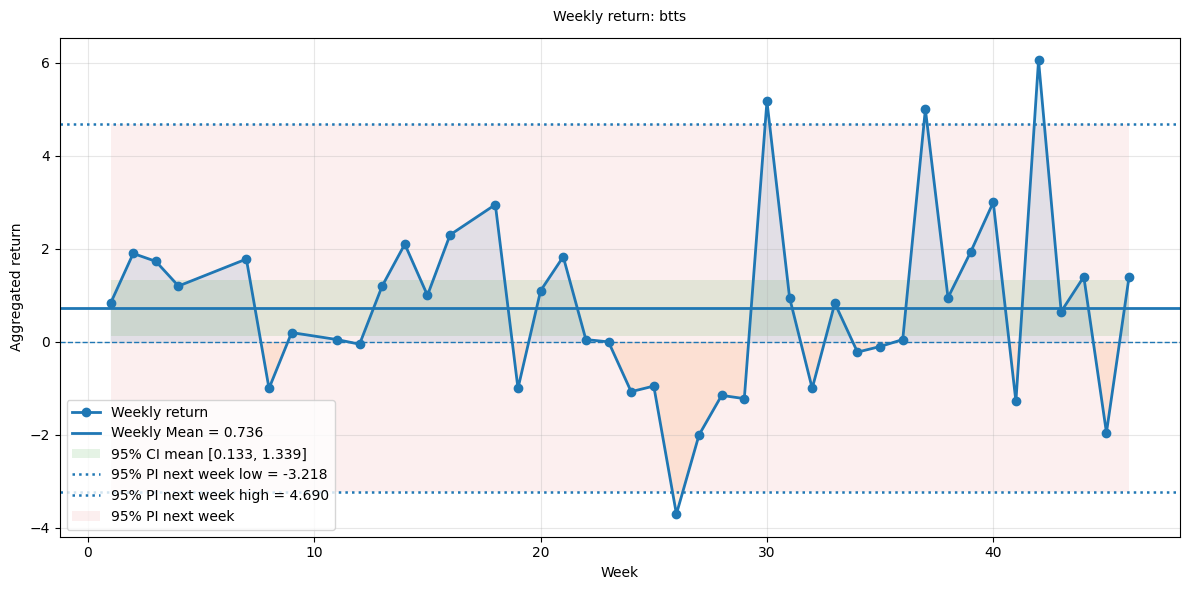

In [3]:
import pandas as pd

# Choose best trial
best_trial = top_trials[0]

df = get_btts_table()
feature_bins_map = best_trial.user_attrs["feature_bins_map"]
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x["goalNoGoal_quote_currentGG"]), axis=1).copy()

# Adding week column 
df["week"] = df["time"].dt.to_period("W")
monday_start = df["time"].min() - pd.to_timedelta(df["time"].min().weekday(), unit="D")
df["week"] = ((df["time"] - monday_start).dt.days // 7) + 1

# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)
 
df_binned["strategy"] = target_col


mask = get_mask(df_binned, study.best_trial.user_attrs["params_dict"])

df_filtered = df_binned[mask]
weekly_return, stats = analyze_strategies(df_filtered, strategies=[target_col], print_pi=True)
